# Step 5 — Summary Dashboard

**目標**：整合所有分析結果

**修改下方 PARAMS cell 的參數後，Run All Cells**

In [1]:
# ===== 共用參數 =====
exec(open('../config/params.py').read())
# ==============================

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.gridspec import GridSpec

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
REPORTS_DIR = Path('../reports')

df = pd.read_csv(DATA_PATH)
df['order_created_at'] = pd.to_datetime(df['order_created_at'], format=DATETIME_FORMAT)
sys_flags = pd.read_csv('../data/system_anomaly_flags.csv')
usr_flags = pd.read_csv('../data/user_anomaly_flags.csv')
df = df.merge(sys_flags, on='order_id').merge(usr_flags, on='order_id')

normal = df[~(df['is_system_anomaly'] | df['is_user_anomaly'])].copy()
anomaly_total = (df['is_system_anomaly'] | df['is_user_anomaly']).sum()

# Phase estimation
normal['est_queue'] = normal['queue_duration_seconds']
normal['est_db'] = normal['db_duration_avg_seconds'] * normal['file_count'] / PARALLELISM
normal['est_device'] = normal['device_duration_avg_seconds'] * normal['file_count'] / PARALLELISM
normal['est_inner'] = normal['inner_processing_duration_avg_seconds'] * normal['file_count'] / PARALLELISM

phase_means = normal[['est_queue', 'est_db', 'est_device', 'est_inner']].mean()
phase_pct = (phase_means / phase_means.sum() * 100).round(1)

# Slow device detection (replicate step4 logic exactly)
device_medians = normal.groupby('device_id')['device_duration_avg_seconds'].median().sort_values(ascending=False)
if len(device_medians) < 2:
    slow_device_ids = []
    n_slow = 0
else:
    gaps = device_medians.diff(-1).abs()
    max_gap_id = gaps.idxmax()
    gap_pos = list(device_medians.index).index(max_gap_id)
    gap_value = gaps[max_gap_id]
    next_value = device_medians.iloc[gap_pos + 1] if gap_pos + 1 < len(device_medians) else 0
    gap_ratio = gap_value / next_value if next_value > 0 else float('inf')
    if gap_ratio >= GAP_MIN_RATIO:
        slow_device_ids = list(device_medians.index[:gap_pos + 1])
    else:
        global_p99 = device_medians.quantile(0.99)
        slow_device_ids = list(device_medians[device_medians > global_p99].index)
    n_slow = len(slow_device_ids)


## Executive Summary

In [3]:
print("=" * 60)
print("EXECUTIVE SUMMARY")
print("=" * 60)

print(f"\n1. 資料概觀")
print(f"   總訂單: {len(df):,}")
print(f"   異常: {anomaly_total:,} ({100*anomaly_total/len(df):.1f}%)")
print(f"   正常: {len(normal):,}")
print(f"   平均耗時(正常): {normal['total_duration_seconds'].mean():.0f}s "
      f"(median: {normal['total_duration_seconds'].median():.0f}s)")

print(f"\n2. 系統異常: {df['is_system_anomaly'].sum():,} ({100*df['is_system_anomaly'].mean():.1f}%)")
print(f"3. User contention: {df['is_user_anomaly'].sum():,} ({100*df['is_user_anomaly'].mean():.1f}%)")

print(f"\n4. 正常訂單瓶頸")
print(f"   Queue:  {phase_pct['est_queue']:.1f}% (avg {phase_means['est_queue']:.0f}s)")
print(f"   DB:     {phase_pct['est_db']:.1f}% (avg {phase_means['est_db']:.0f}s)")
print(f"   Device: {phase_pct['est_device']:.1f}% (avg {phase_means['est_device']:.0f}s)")
print(f"   Inner:  {phase_pct['est_inner']:.1f}% (avg {phase_means['est_inner']:.0f}s)")
print(f"   主要瓶頸: {phase_pct.idxmax().replace('est_', '').upper()}")

print(f"\n5. 慢機台: {n_slow} 台")
for d in slow_device_ids:
    print(f"   {d}: median={device_medians[d]:.1f}s")


# Label distribution (if anomaly_type column exists)
if 'anomaly_type' in df.columns:
    print(f"\n6. 訂單 Label 分佈  （每筆訂單的分類）")
    label_dist = df['anomaly_type'].value_counts()
    for label, count in label_dist.items():
        print(f"   {label}: {count:,} ({100*count/len(df):.1f}%)")
else:
    # Merge anomaly_type from system_anomaly_flags if available
    sf = pd.read_csv('../data/system_anomaly_flags.csv')
    if 'anomaly_type' in sf.columns:
        label_df = df[['order_id']].merge(sf[['order_id', 'anomaly_type']], on='order_id', how='left')
        label_df['anomaly_type'] = label_df['anomaly_type'].fillna('normal')
        print(f"\n6. 訂單 Label 分佈  （每筆訂單的分類）")
        label_dist = label_df['anomaly_type'].value_counts()
        for label, count in label_dist.items():
            print(f"   {label}: {count:,} ({100*count/len(df):.1f}%)")


EXECUTIVE SUMMARY

1. 資料概觀
   總訂單: 30,000
   異常: 936 (3.1%)
   正常: 29,064
   平均耗時(正常): 261s (median: 82s)

2. 系統異常: 933 (3.1%)
3. User contention: 3 (0.0%)

4. 正常訂單瓶頸
   Queue:  0.5% (avg 1s)
   DB:     3.0% (avg 8s)
   Device: 79.7% (avg 202s)
   Inner:  16.9% (avg 43s)
   主要瓶頸: DEVICE

5. 慢機台: 20 台
   DEV-1827: median=12.6s
   DEV-0476: median=11.1s
   DEV-0569: median=9.6s
   DEV-0065: median=9.5s
   DEV-1650: median=9.5s
   DEV-1116: median=9.4s
   DEV-0178: median=9.4s
   DEV-0919: median=9.3s
   DEV-0228: median=9.2s
   DEV-0054: median=9.2s
   DEV-1385: median=8.7s
   DEV-1657: median=8.7s
   DEV-1330: median=8.7s
   DEV-0451: median=8.6s
   DEV-1034: median=8.5s
   DEV-0563: median=8.4s
   DEV-1466: median=8.1s
   DEV-1209: median=8.0s
   DEV-0051: median=7.9s
   DEV-1436: median=7.9s

6. 訂單 Label 分佈  （每筆訂單的分類）
   normal: 29,064 (96.9%)
   device_timeout: 353 (1.2%)
   queue_stuck: 295 (1.0%)
   db_lock: 280 (0.9%)
   queue_stuck, device_timeout: 4 (0.0%)
   user_contention: 3 

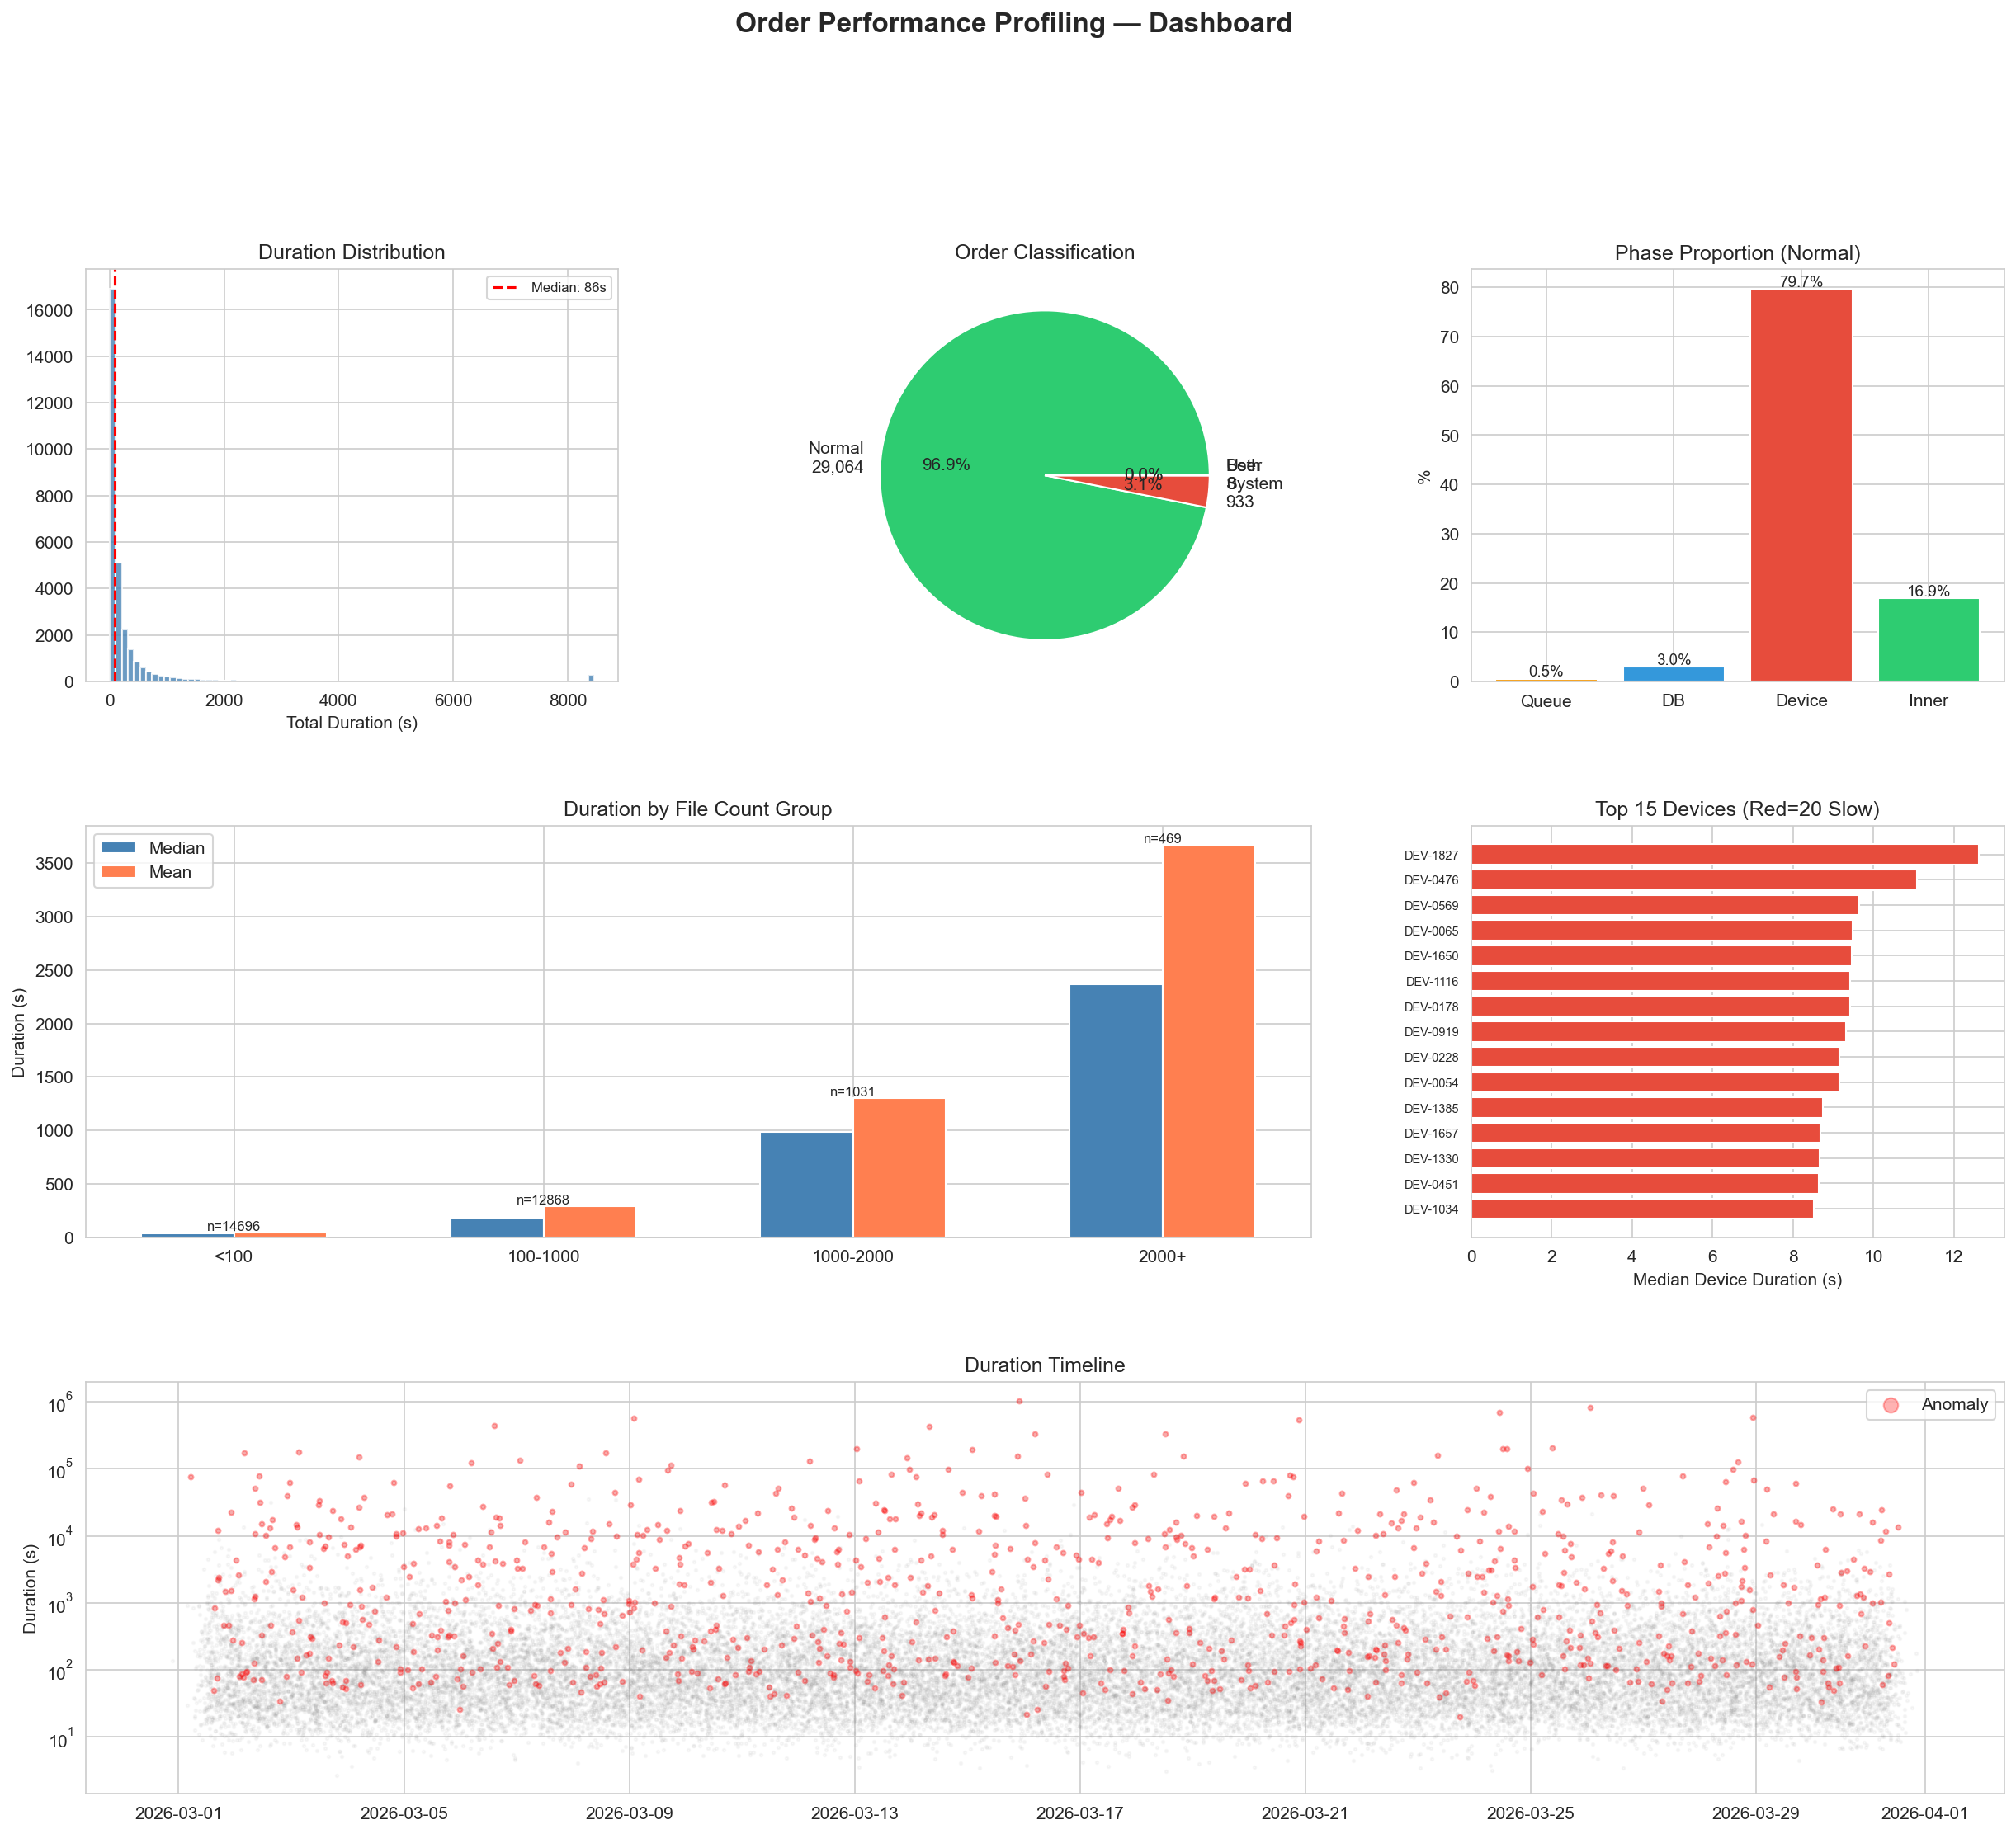

Saved: reports/dashboard.png


In [4]:
# Dashboard chart
fig = plt.figure(figsize=(20, 16))
gs = GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.3)

# 1: Duration distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df['total_duration_seconds'].clip(upper=df['total_duration_seconds'].quantile(0.99)*1.2),
         bins=80, color='steelblue', edgecolor='white', alpha=0.8)
ax1.axvline(x=df['total_duration_seconds'].median(), color='red', linestyle='--',
            label=f"Median: {df['total_duration_seconds'].median():.0f}s")
ax1.set_title('Duration Distribution')
ax1.set_xlabel('Total Duration (s)')
ax1.legend(fontsize=8)

# 2: Classification pie
ax2 = fig.add_subplot(gs[0, 1])
sys_only = (df['is_system_anomaly'] & ~df['is_user_anomaly']).sum()
usr_only = (~df['is_system_anomaly'] & df['is_user_anomaly']).sum()
both = (df['is_system_anomaly'] & df['is_user_anomaly']).sum()
sizes = [len(normal), sys_only, usr_only, both]
pie_labels = [f'Normal\n{len(normal):,}', f'System\n{sys_only:,}', f'User\n{usr_only:,}', f'Both\n{both:,}']
ax2.pie(sizes, labels=pie_labels, colors=['#2ecc71','#e74c3c','#f39c12','#8e44ad'], autopct='%1.1f%%')
ax2.set_title('Order Classification')

# 3: Phase proportion
ax3 = fig.add_subplot(gs[0, 2])
bars = ax3.bar(['Queue','DB','Device','Inner'],
               [phase_pct['est_queue'],phase_pct['est_db'],phase_pct['est_device'],phase_pct['est_inner']],
               color=['#f39c12','#3498db','#e74c3c','#2ecc71'])
ax3.set_title('Phase Proportion (Normal)')
ax3.set_ylabel('%')
for bar, val in zip(bars, phase_pct.values):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val:.1f}%', ha='center', fontsize=9)

# 4: Duration by group
ax4 = fig.add_subplot(gs[1, 0:2])
normal['fc_group'] = pd.cut(normal['file_count'], bins=FILE_COUNT_BINS, labels=FILE_COUNT_LABELS, right=True)
grp = normal.groupby('fc_group', observed=True)['total_duration_seconds'].agg(['median','mean','count'])
x = range(len(grp))
ax4.bar([i-0.15 for i in x], grp['median'], width=0.3, label='Median', color='steelblue')
ax4.bar([i+0.15 for i in x], grp['mean'], width=0.3, label='Mean', color='coral')
ax4.set_xticks(list(x))
ax4.set_xticklabels(grp.index)
ax4.set_title('Duration by File Count Group')
ax4.set_ylabel('Duration (s)')
ax4.legend()
for i, cnt in enumerate(grp['count']):
    ax4.text(i, grp['mean'].iloc[i]+20, f'n={cnt}', ha='center', fontsize=8)

# 5: Top devices
ax5 = fig.add_subplot(gs[1, 2])
top15 = device_medians.head(15)
colors_dev = ['#e74c3c' if d in slow_device_ids else '#3498db' for d in top15.index]
ax5.barh(range(len(top15)), top15.values, color=colors_dev)
ax5.set_yticks(range(len(top15)))
ax5.set_yticklabels(top15.index, fontsize=7)
ax5.set_title(f'Top 15 Devices (Red={n_slow} Slow)')
ax5.set_xlabel('Median Device Duration (s)')
ax5.invert_yaxis()

# 6: Timeline
ax6 = fig.add_subplot(gs[2, :])
ax6.scatter(df['order_created_at'], df['total_duration_seconds'], alpha=0.05, s=3, c='gray')
anom_mask = df['is_system_anomaly'] | df['is_user_anomaly']
ax6.scatter(df.loc[anom_mask, 'order_created_at'], df.loc[anom_mask, 'total_duration_seconds'],
            alpha=0.3, s=8, c='red', label='Anomaly')
ax6.set_title('Duration Timeline')
ax6.set_ylabel('Duration (s)')
ax6.set_yscale('log')
ax6.legend(markerscale=3)

plt.suptitle('Order Performance Profiling — Dashboard', fontsize=16, fontweight='bold', y=1.01)
plt.savefig(REPORTS_DIR / 'dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: reports/dashboard.png")


In [5]:
# Export executive summary to reports/
summary = []
summary.append("=" * 60)
summary.append("Step 5 — Executive Summary")
summary.append("=" * 60)
summary.append(f"\n1. 資料概觀")
summary.append(f"   總訂單: {len(df):,}")
summary.append(f"   異常: {anomaly_total:,} ({100*anomaly_total/len(df):.1f}%)  （被標記為系統異常或 user contention 的訂單）")
summary.append(f"   正常: {len(normal):,}  （用於瓶頸分析的訂單）")
summary.append(f"   平均耗時(正常): {normal['total_duration_seconds'].mean():.0f}s (median: {normal['total_duration_seconds'].median():.0f}s)")
summary.append(f"     （mean 受極端值影響，median 更能代表典型訂單耗時）")
summary.append(f"\n2. 系統異常: {df['is_system_anomaly'].sum():,} ({100*df['is_system_anomaly'].mean():.1f}%)")
summary.append(f"     （device timeout / DB lock / queue stuck 等系統問題導致的異常訂單）")
summary.append(f"3. User contention: {df['is_user_anomaly'].sum():,} ({100*df['is_user_anomaly'].mean():.1f}%)")
summary.append(f"     （同 device 短時間多單造成的 contention）")
summary.append(f"\n4. 正常訂單瓶頸  （各階段佔 order 總耗時的比例）")
summary.append(f"   Queue:  {phase_pct['est_queue']:.1f}% (avg {phase_means['est_queue']:.0f}s)  — 等 consumer 撿起")
summary.append(f"   DB:     {phase_pct['est_db']:.1f}% (avg {phase_means['est_db']:.0f}s)  — 查詢 golden file list")
summary.append(f"   Device: {phase_pct['est_device']:.1f}% (avg {phase_means['est_device']:.0f}s)  — 對設備下 command")
summary.append(f"   Inner:  {phase_pct['est_inner']:.1f}% (avg {phase_means['est_inner']:.0f}s)  — file check 處理")
summary.append(f"   主要瓶頸: {phase_pct.idxmax().replace('est_', '').upper()}  ← 優化首要目標")
summary.append(f"\n5. 慢機台: {n_slow} 台  （device_duration median 明顯高於其他 device）")
for d in slow_device_ids[:10]:
    summary.append(f"   {d}: median={device_medians[d]:.1f}s")
if n_slow > 10:
    summary.append(f"   ... 及其他 {n_slow - 10} 台")

# Label distribution
sf = pd.read_csv('../data/system_anomaly_flags.csv')
if 'anomaly_type' in sf.columns:
    label_df = df[['order_id']].merge(sf[['order_id', 'anomaly_type']], on='order_id', how='left')
    label_df['anomaly_type'] = label_df['anomaly_type'].fillna('normal')
    summary.append(f"\n6. 訂單 Label 分佈  （每筆訂單的最終分類）")
    for label, count in label_df['anomaly_type'].value_counts().items():
        desc_map = {'normal': '正常訂單',
                'user_contention': '同 device 多單搶佔',
                'device_timeout': 'device command 異常久',
                'db_lock': 'DB 查詢異常久',
                'queue_stuck': 'queue 等待異常久'}
        if label in desc_map:
            desc = desc_map[label]
        else:
            # Multi-label: join descriptions
            parts = [desc_map.get(l.strip(), l.strip()) for l in label.split(',')]
            desc = ' + '.join(parts)
        summary.append(f"   {label}: {count:,} ({100*count/len(df):.1f}%)  （{desc}）")

with open(str(REPORTS_DIR / 'step5_summary.txt'), 'w') as f:
    f.write('\n'.join(summary))
print(f"Saved: reports/step5_summary.txt")


Saved: reports/step5_summary.txt
